In [28]:
from pyspark.sql import SparkSession

# Créer la SparkSession
spark = SparkSession.builder     .appName("ProjetBigData - MovieLens")     .getOrCreate()

In [29]:
# Lire les fichiers CSV depuis HDFS
ratings_df = spark.read.csv("hdfs://namenode:9000/datasets/rating.csv", header=True, inferSchema=True)
movies_df = spark.read.csv("hdfs://namenode:9000/datasets/movie.csv", header=True, inferSchema=True)

# Afficher les premières lignes
ratings_df.show(5)
movies_df.show(5)

+------+-------+------+-------------------+
|userId|movieId|rating|          timestamp|
+------+-------+------+-------------------+
|     1|      2|   3.5|2005-04-02 23:53:47|
|     1|     29|   3.5|2005-04-02 23:31:16|
|     1|     32|   3.5|2005-04-02 23:33:39|
|     1|     47|   3.5|2005-04-02 23:32:07|
|     1|     50|   3.5|2005-04-02 23:29:40|
+------+-------+------+-------------------+
only showing top 5 rows

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows



In [30]:
# Installer les packages manquants directement depuis Jupyter
!pip install --no-cache-dir pandas matplotlib seaborn numpy


In [31]:
!pip install pyspark

In [32]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
spark = SparkSession.builder.appName("MovieLens").getOrCreate()

25/04/30 09:10:23 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [34]:
ratings_df.printSchema()
movies_df.printSchema()
ratings_df.show(5)
movies_df.show(5)

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: timestamp (nullable = true)

root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

+------+-------+------+-------------------+
|userId|movieId|rating|          timestamp|
+------+-------+------+-------------------+
|     1|      2|   3.5|2005-04-02 23:53:47|
|     1|     29|   3.5|2005-04-02 23:31:16|
|     1|     32|   3.5|2005-04-02 23:33:39|
|     1|     47|   3.5|2005-04-02 23:32:07|
|     1|     50|   3.5|2005-04-02 23:29:40|
+------+-------+------+-------------------+
only showing top 5 rows

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...| 

In [35]:
ratings_df.describe().show()
print("Nombre d'utilisateurs :", ratings_df.select("userId").distinct().count())
print("Nombre de films :", ratings_df.select("movieId").distinct().count())
print("Nombre total de notes :", ratings_df.count())

+-------+-----------------+-----------------+------------------+
|summary|           userId|          movieId|            rating|
+-------+-----------------+-----------------+------------------+
|  count|         20000263|         20000263|          20000263|
|   mean|69045.87258292554|9041.567330339605|3.5255285642993797|
| stddev| 40038.6266531621|  19789.477445413| 1.051988919294244|
|    min|                1|                1|               0.5|
|    max|           138493|           131262|               5.0|
+-------+-----------------+-----------------+------------------+



Nombre d'utilisateurs : 138493


Nombre de films : 26744


[Stage 131:>                                                      (0 + 16) / 16]

Nombre total de notes : 20000263


In [36]:
for col in ratings_df.columns:
    print(f"{col} : {ratings_df.filter(F.col(col).isNull()).count()} valeurs manquantes")
for col in movies_df.columns:
    print(f"{col} : {movies_df.filter(F.col(col).isNull()).count()} valeurs manquantes")

print("Doublons ratings :", ratings_df.count() - ratings_df.dropDuplicates().count())
print("Doublons movies :", movies_df.count() - movies_df.dropDuplicates().count())

userId : 0 valeurs manquantes


movieId : 0 valeurs manquantes


rating : 0 valeurs manquantes


timestamp : 0 valeurs manquantes
movieId : 0 valeurs manquantes
title : 0 valeurs manquantes
genres : 0 valeurs manquantes


25/04/30 09:11:05 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:05 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:05 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:05 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:05 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:05 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:05 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:05 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:05 WARN RowBasedKeyValueBatch: Calling spill() on

[946.768s][warning][gc,alloc] Executor task launch worker for task 3.0 in stage 160.0 (TID 595): Retried waiting for GCLocker too often allocating 406231 words


25/04/30 09:11:21 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:21 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:21 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:21 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:21 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:21 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:21 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:21 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:21 WARN RowBasedKeyValueBatch: Calling spill() on

Doublons ratings : 0
Doublons movies : 0


In [37]:
# Suppression des doublons
ratings_df = ratings_df.dropDuplicates()
movies_df = movies_df.dropDuplicates()

# Suppression des valeurs manquantes
ratings_df = ratings_df.dropna()
movies_df = movies_df.dropna()

25/04/30 09:11:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:31 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:31 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:31 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:31 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:31 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:31 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:31 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:31 WARN RowBasedKeyValueBatch: Calling spill() on

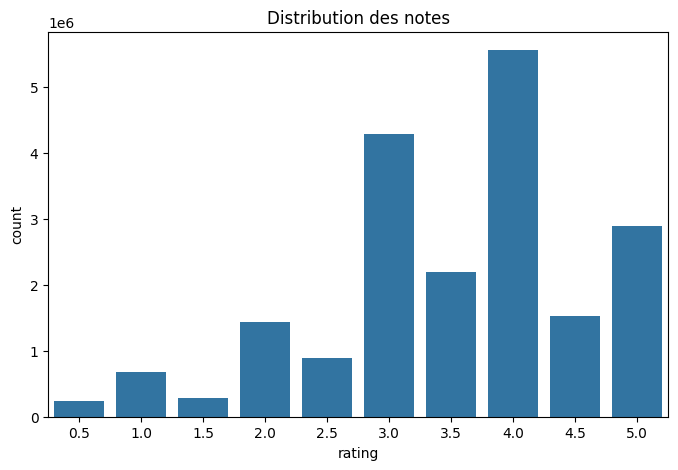

In [38]:
ratings_dist = ratings_df.groupBy("rating").count().orderBy("rating")
ratings_pd = ratings_dist.toPandas()
plt.figure(figsize=(8,5))
sns.barplot(x="rating", y="count", data=ratings_pd)
plt.title("Distribution des notes")
plt.show()

In [39]:
top_movies = ratings_df.groupBy("movieId").count().orderBy(F.desc("count")).limit(10)
top_movies = top_movies.join(movies_df, "movieId")
top_movies.select("title", "count").show(truncate=False)

25/04/30 09:11:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:11:57 WARN RowBasedKeyValueBatch: Calling spill() on

+-----------------------------------------+-----+
|title                                    |count|
+-----------------------------------------+-----+
|Pulp Fiction (1994)                      |67310|
|Jurassic Park (1993)                     |59715|
|Forrest Gump (1994)                      |66172|
|Shawshank Redemption, The (1994)         |63366|
|Silence of the Lambs, The (1991)         |63299|
|Braveheart (1995)                        |53769|
|Star Wars: Episode IV - A New Hope (1977)|54502|
|Terminator 2: Judgment Day (1991)        |52244|
|Matrix, The (1999)                       |51334|
|Schindler's List (1993)                  |50054|
+-----------------------------------------+-----+



In [40]:
ratings_df = ratings_df.withColumn("userId", F.col("userId").cast("int"))
ratings_df = ratings_df.withColumn("movieId", F.col("movieId").cast("int"))
ratings_df = ratings_df.withColumn("rating", F.col("rating").cast("float"))

In [41]:
ratings_small = ratings_df.sample(fraction=0.1, seed=42)


In [42]:
(training, test) = ratings_small.randomSplit([0.8, 0.2], seed=42)

In [43]:
als = ALS(
    maxIter=10,
    regParam=0.1,
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    coldStartStrategy="drop"
)
model = als.fit(training)

25/04/30 09:12:25 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:12:25 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:12:25 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:12:25 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:12:25 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:12:25 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:12:25 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:12:25 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:12:25 WARN RowBasedKeyValueBatch: Calling spill() on

In [44]:
predictions = model.transform(test)
evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)
rmse = evaluator.evaluate(predictions)
print(f"RMSE du modèle : {rmse:.4f}")

25/04/30 09:13:35 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:13:35 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:13:35 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:13:35 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:13:35 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:13:36 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:13:36 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:13:36 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:13:36 WARN RowBasedKeyValueBatch: Calling spill() on

RMSE du modèle : 0.9415


In [45]:
userRecs = model.recommendForAllUsers(5)
userRecs.show(5, truncate=False)

[Stage 364:====================================================> (98 + 2) / 100]

+------+---------------------------------------------------------------------------------------------------+
|userId|recommendations                                                                                    |
+------+---------------------------------------------------------------------------------------------------+
|31    |[{4185, 5.941403}, {6599, 5.873305}, {3447, 5.626134}, {26512, 5.5428863}, {55946, 5.538692}]      |
|34    |[{101425, 6.246217}, {98595, 5.860191}, {6599, 5.82964}, {73710, 5.817712}, {109420, 5.77641}]     |
|53    |[{98595, 6.1532583}, {101425, 6.1012125}, {8647, 5.906712}, {73529, 5.7503414}, {68874, 5.6251774}]|
|65    |[{115708, 5.3656254}, {48231, 5.342335}, {128812, 5.266564}, {99058, 5.08416}, {5798, 4.920973}]   |
|78    |[{7879, 5.4981184}, {73710, 5.3709865}, {26136, 5.104475}, {32825, 5.081658}, {2593, 5.068515}]    |
+------+---------------------------------------------------------------------------------------------------+
only showing top 5 

In [46]:
user_id = 1
user_subset = ratings_df.select("userId").where(F.col("userId") == user_id).distinct()
recs = model.recommendForUserSubset(user_subset, 5)
recs.show(truncate=False)

+------+--------------------------------------------------------------------------------------------------+
|userId|recommendations                                                                                   |
+------+--------------------------------------------------------------------------------------------------+
|1     |[{109420, 5.375884}, {98595, 5.363261}, {6599, 5.2595162}, {101425, 5.2476735}, {8647, 5.1734986}]|
+------+--------------------------------------------------------------------------------------------------+



In [47]:
from pyspark.sql.functions import explode

recs_exploded = recs.withColumn("rec", explode("recommendations")) \
    .select("userId", F.col("rec.movieId"), F.col("rec.rating"))
recs_with_titles = recs_exploded.join(movies_df, "movieId")
recs_with_titles.select("userId", "title", "rating").show(truncate=False)

+------+---------------------------------------+---------+
|userId|title                                  |rating   |
+------+---------------------------------------+---------+
|1     |Mater and the Ghostlight (2006)        |5.375884 |
|1     |Peppermint Soda (Diabolo menthe) (1977)|5.363261 |
|1     |Accattone (1961)                       |5.2595162|
|1     |Company (2011)                         |5.2476735|
|1     |Follow That Dream (1962)               |5.1734986|
+------+---------------------------------------+---------+



In [48]:
# On suppose que recs_with_titles est déjà créé comme dans l’étape 9.3
recs_pd = recs_with_titles.toPandas()

In [49]:
import pandas as pd
from IPython.display import display

display(recs_pd)

,movieId,userId,rating,title,genres
0,109420,1,5.375884,Mater and the Ghostlight (2006),Animation|Children|Comedy
1,98595,1,5.363261,Peppermint Soda (Diabolo menthe) (1977),Comedy|Drama
2,6599,1,5.259516,Accattone (1961),Drama
3,101425,1,5.247674,Company (2011),Drama|Musical
4,8647,1,5.173499,Follow That Dream (1962),Comedy|Musical


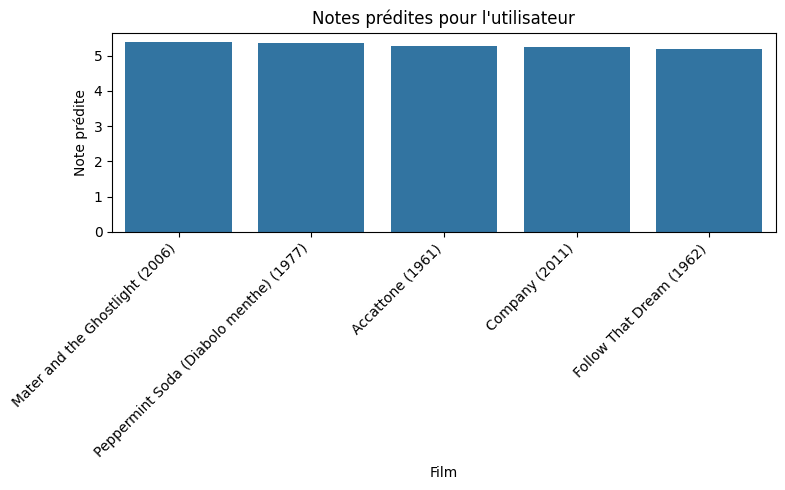

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x="title", y="rating", data=recs_pd)
plt.title("Notes prédites pour l'utilisateur")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Note prédite")
plt.xlabel("Film")
plt.tight_layout()
plt.show()

25/04/30 09:14:49 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:14:49 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:14:49 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:14:49 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:14:49 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:14:49 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:14:49 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:14:49 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/04/30 09:14:49 WARN RowBasedKeyValueBatch: Calling spill() on

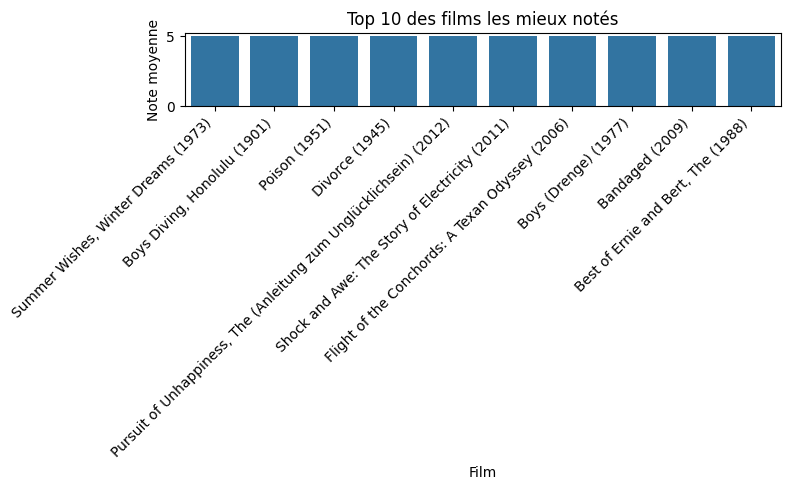

In [51]:
top_movies = ratings_df.groupBy("movieId").agg(F.count("rating").alias("nb_ratings"), F.avg("rating").alias("avg_rating"))
top_movies = top_movies.join(movies_df, "movieId").orderBy(F.desc("avg_rating"))
top_movies_pd = top_movies.toPandas().sort_values(by="avg_rating", ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x="title", y="avg_rating", data=top_movies_pd)
plt.title("Top 10 des films les mieux notés")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Note moyenne")
plt.xlabel("Film")
plt.tight_layout()
plt.show()